# <center> Elementy numerycznej algebry liniowej </center>

Rozwiązywanie układów równań liniowych jest jednym z podstawowych problemów metod numerycznych. Układy równań liniowych występują w wielu dziedzinach nauki i inżynierii. Stosuje się też w uczeniu maszynowym np. podczas regresji z błędem średniokwadratowym. 


Istnieje kilka metod rozwiązywania układów równań. Na dzisiejszych zajęciach zajmiemy się:
* eliminacją Gaussa bez oraz z wyborem elementu głównego,
* metodami iteracyjnymi.

Problem rozwiązywania układu równań liniowych będzie nam towarzyszły do końca zajęć z tego przedmiotu.

## Normy i wskaźniki uwarunkowania

Wrażliwość układu (zmiana rozwiązania) na niewielkie zaburzenia wektora `b` zależy od macierzy `A` i ocenia się ja za pomocą tzw. współczynnika lub [wskaźnika uwarunkowania macierzy](https://pl.wikipedia.org/wiki/Wskaźnik_uwarunkowania) (ang. *condition number*). Im wyższa wartość tego wskaźnika. tym macierz jest gorzej uwarunkowana. Wskaźnik uwarunkowania to iloczyn normy macierzy z normą jej odwrotności.

$$cond(A)=|A|_{p}\cdot|A^{-1}|_{p}$$
gdzie *p* oznacza jedną z norm macierzy.

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

***Zadanie 1.***

Porównaj normy 1,2, $\infty$ następujących macierzy:
* [Hilberta](https://pl.wikipedia.org/wiki/Macierz_Hilberta): o wymiarach 5x5 i 15x15
* [Vandermonde'a](https://pl.wikipedia.org/wiki/Macierz_Vandermonde’a): o wymiarach 5x5 i 15x15
* losowej o wartościach z przedziału [0,1]:  o wymiarach 5x5 i 15x15
* $P=\left[\begin{array}{cccc}4 & 1 & -1 & 0 \\ 1 & 3 & -1 & 0 \\ -1 & -1 & 5 & 2 \\ 0 & 0 & 2 & 4\end{array}\right]$

Czy wśród powyższych macierzy jest macierz [diagonalnie dominująca](https://pl.wikipedia.org/wiki/Macierz_przekątniowo_dominująca)?


In [1]:
import numpy as np
from scipy.linalg import hilbert


def is_diagonally_dominant(A):
    
    diag = np.abs(np.diag(A))
    
    off_diag_sum = np.sum(np.abs(A), axis=1) - diag
    
    return np.all(diag > off_diag_sum)


def analyze_matrix(name, A):
    norm1 = np.linalg.norm(A, 1)
    norm2 = np.linalg.norm(A, 2)
    norm_inf = np.linalg.norm(A, np.inf)
    is_diag_dom = is_diagonally_dominant(A)
    
    print(f"--- {name} ---")
    print(f"  Norma 1:  {norm1:.4e}")
    print(f"  Norma 2:  {norm2:.4e}")
    print(f"  Norma inf: {norm_inf:.4e}")
    print(f"  Diagonalnie dominująca: {'TAK' if is_diag_dom else 'NIE'}\n")


sizes = [5, 15]

for n in sizes:
    print(f"=== WYMIARY {n}x{n} ===")
    
  
    H = hilbert(n)
    analyze_matrix(f"Macierz Hilberta {n}x{n}", H)
    
    
    v = np.arange(1, n + 1)
    V = np.vander(v)
    analyze_matrix(f"Macierz Vandermonde'a {n}x{n}", V)
    
    
    R = np.random.rand(n, n)
    analyze_matrix(f"Macierz losowa {n}x{n}", R)

print("=== MACIERZ P ===")
P = np.array([
    [4,  1, -1,  0],
    [1,  3, -1,  0],
    [-1, -1,  5,  2],
    [0,  0,  2,  4]
])
analyze_matrix("Macierz P", P)

=== WYMIARY 5x5 ===
--- Macierz Hilberta 5x5 ---
  Norma 1:  2.2833e+00
  Norma 2:  1.5671e+00
  Norma inf: 2.2833e+00
  Diagonalnie dominująca: NIE

--- Macierz Vandermonde'a 5x5 ---
  Norma 1:  9.7900e+02
  Norma 2:  6.9584e+02
  Norma inf: 7.8100e+02
  Diagonalnie dominująca: NIE

--- Macierz losowa 5x5 ---
  Norma 1:  3.4786e+00
  Norma 2:  2.9714e+00
  Norma inf: 4.1155e+00
  Diagonalnie dominująca: NIE

=== WYMIARY 15x15 ===
--- Macierz Hilberta 15x15 ---
  Norma 1:  3.3182e+00
  Norma 2:  1.8459e+00
  Norma inf: 3.3182e+00
  Diagonalnie dominująca: NIE

--- Macierz Vandermonde'a 15x15 ---
  Norma 1:  4.6034e+16
  Norma 2:  3.1584e+16
  Norma inf: 3.1278e+16
  Diagonalnie dominująca: NIE

--- Macierz losowa 15x15 ---
  Norma 1:  8.9939e+00
  Norma 2:  7.6209e+00
  Norma inf: 9.8159e+00
  Diagonalnie dominująca: NIE

=== MACIERZ P ===
--- Macierz P ---
  Norma 1:  9.0000e+00
  Norma 2:  7.0861e+00
  Norma inf: 9.0000e+00
  Diagonalnie dominująca: TAK



Macierz Hilberta, Vandermonde'a i losowe nie są diagonalnie dominujące. Wynika to z ich specyficznej budowy (np. w macierzy losowej [0,1] na przekątnej mamy wartości z tego samego przedziału co reszta, więc ich suma na pewno przebije wartość na przekątnej).Jedyną macierzą diagonalnie dominującą w tym zestawieniu jest macierz $P$.Możemy to udowodnić nawet bez komputera (ręcznie):Wiersz 1: $|4| > |1| + |-1| + |0|$ $\rightarrow$ $4 > 2$ (Prawda)Wiersz 2: $|3| > |1| + |-1| + |0|$ $\rightarrow$ $3 > 2$ (Prawda)Wiersz 3: $|5| > |-1| + |-1| + |2|$ $\rightarrow$ $5 > 4$ (Prawda)Wiersz 4: $|4| > |0| + |0| + |2|$ $\rightarrow$ $4 > 2$ (Prawda)Warunek jest spełniony dla każdego wiersza, więc macierz $P$ jest ściśle diagonalnie dominująca.

*Wskazówka: Do wyznaczenia norm możesz wykorzystać funkcję `numpy.linalg.norm`*

***Zadanie 2.***

Oblicz wskaźniki uwarunkowania macierzy z poprzedniego zadania.

*Wskazówka: Możesz wykorzystać funkcję `numpy.linalg.cond`.*

In [2]:
import numpy as np
from scipy.linalg import hilbert


sizes = [5, 15]

for n in sizes:
    print(f"=== Wskaźniki uwarunkowania dla wymiarów {n}x{n} ===")
    
    
    H = hilbert(n)
    cond_H = np.linalg.cond(H)
    print(f"Macierz Hilberta:       {cond_H:.4e}")
    
  
    v = np.arange(1, n + 1)
    V = np.vander(v)
    cond_V = np.linalg.cond(V)
    print(f"Macierz Vandermonde'a:  {cond_V:.4e}")
    

    R = np.random.rand(n, n)
    cond_R = np.linalg.cond(R)
    print(f"Macierz losowa:         {cond_R:.4e}\n")


print("=== Wskaźnik uwarunkowania dla macierzy P ===")
P = np.array([
    [4,  1, -1,  0],
    [1,  3, -1,  0],
    [-1, -1,  5,  2],
    [0,  0,  2,  4]
])
cond_P = np.linalg.cond(P)
print(f"Macierz P:              {cond_P:.4f}")

=== Wskaźniki uwarunkowania dla wymiarów 5x5 ===
Macierz Hilberta:       4.7661e+05
Macierz Vandermonde'a:  2.6170e+04
Macierz losowa:         7.6884e+01

=== Wskaźniki uwarunkowania dla wymiarów 15x15 ===
Macierz Hilberta:       3.6757e+17
Macierz Vandermonde'a:  2.5824e+21
Macierz losowa:         1.0018e+03

=== Wskaźnik uwarunkowania dla macierzy P ===
Macierz P:              3.5431


## Rozwiązywanie układów równań metodą eliminacji Gaussa

***Zadanie 3.***

Jedną z metod rozwiązywania układów równań liniowych jest metoda eliminacji Gaussa. Metoda ta występuje w kilku odmianach. Poza podstawowym wariantem, możliwe jest zastosowanie metody z wyborem elementu głownego (tzw. *pivoting*). 

Celem tego zadania jest porównanie błędów rozwiązania otrzymanego z tych dwóch wariantów eliminacji Gaussa. Poniżej znajdują się implementacje obu tych metod. Każda z funkcji przyjmuje macierz `A` oraz wektor prawej strony równania `b`.

Samo polecenie znajduje się poniżej.

In [ ]:
def gauss_pivot(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j,k]) > abs(A[ind_max,k]):
                ind_max = j
        if ind_max > k:
            tmp = A[ind_max,k:n].copy()
            A[ind_max,k:n] = A[k,k:n]
            A[k,k:n] = tmp
            tmp = b[ind_max].copy()
            b[ind_max] = b[k]
            b[k] = tmp
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1]/A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

In [ ]:
def gauss(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

Stwórz macierze wartości losowych `A` o wymiarach 10x10 oraz wektor `b` o odpowiednich wymiarach. 
Chcemy rozwiązać układ równań `Ax=b` metodami eliminacji Gaussa bez oraz z wyborem elementu głównego, a następnie porównać dokładność wyników. Metoda z wyborem elementu głównego powinna dawać mniejszy błąd w przypadku dużych wartości znajdujących się na przekątnej. Sprawdź czy to prawda powtarzając obliczenia z  macierzami `A` zawierającym na pierwszym elemencie przekątnej coraz to mniejsze wartości (tak aby wzrosło znaczenie dalszych elementów na przękątnej i tym samym uaktywnił się wybór innego niż pierwszy elementu głównego).

Wskazówka:Do porównania możesz wykorzystać residuum. Jeżeli `x` jest rozwiązaniem układu to `Ax` powinno być równe `b`. Residuum to różnica pomiędzy `b` oraz `Ax`: `res=|b-Ax|`. Możesz porównać zawartości poszczególnych elementów lub obliczyć jakąś normę z otrzymanego wektora.

In [1]:
import numpy as np


def gauss_naive(A, b):
    n = len(b)
    
    M = np.hstack([A.astype(np.float64), b.astype(np.float64).reshape(-1, 1)])
    
    
    for i in range(n):
        for j in range(i + 1, n):
            
            mnoznik = M[j, i] / M[i, i]
            M[j, i:] -= mnoznik * M[i, i:]
            
    
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (M[i, -1] - np.dot(M[i, i+1:n], x[i+1:n])) / M[i, i]
        
    return x


n = 10
np.random.seed(42) 
A_base = np.random.rand(n, n)
b = np.random.rand(n)


epsilons = [1.0, 1e-4, 1e-8, 1e-12, 1e-16]

print(f"{'A[0,0]':<10} | {'Residuum naiwne':<20} | {'Residuum z wyborem (Numpy)'}")
print("-" * 65)

for eps in epsilons:
    A = A_base.copy()
    A[0, 0] = eps
    
    
    try:
        x_naive = gauss_naive(A, b)
        
        res_naive = np.linalg.norm(b - A @ x_naive)
    except Exception as e:
        res_naive = float('inf') 
        
   
    x_pivot = np.linalg.solve(A, b)
    res_pivot = np.linalg.norm(b - A @ x_pivot)
    
    print(f"{eps:<10.1e} | {res_naive:<20.4e} | {res_pivot:.4e}")

A[0,0]     | Residuum naiwne      | Residuum z wyborem (Numpy)
-----------------------------------------------------------------
1.0e+00    | 2.3485e-15           | 1.1147e-15
1.0e-04    | 2.3676e-12           | 5.4690e-16
1.0e-08    | 3.2238e-08           | 1.3268e-15
1.0e-12    | 2.0351e-04           | 7.7926e-16
1.0e-16    | 1.1021e+01           | 9.5384e-16


## Metody iteracyjne

Innym sposobem na rozwiązanie układu równań liniowych jest wykorzystanie metod iteracyjnych, które generują ciągi przybliżeń wektora stanowiącego rozwiązanie układu. Państwa zadaniem będzie implementacja i porównanie zbieżności trzech najpopularniejszych metod iteracyjnego rozwiązywania układów równań liniowych

***Zadanie 4.***

Porównanie zbieżności metod Jacobiego, Gaussa-Seidla i Younga (SOR).
* Zaimplementuj solvery rozwiązujące układy równań metodami Jacobiego, Gaussa-Seidela  i Younga (SOR). Każda funkcja powinna przyjmować macierz A i wektor prawej strony b. Dla uproszczenia, dopuszczalne jest wykorzystanie  inv dla obliczenia macierzy odwrotnej do macierzy trójkątnej (w metodzie G-S i Younga).
* Porównaj zbieżność ciągów iteracyjnych otrzymanych 3 metodami dla 3 układów równań (3 macierzy). W metodzie Younga możesz przyjąć np. $ω = 1.2$.
* Dla macierzy, dla której metoda Younga okazała się zbieżna, porównaj zbieżność ciągów iteracyjnych otrzymanych dla wartości $0 < ω < 3$ (dodatkowe).
* Dla jakiej wartości parametru $ω$ zbieżność ciągu iteracyjnego jest najlepsza? Wynik otrzymany na podstawie obserwacji ciągu odchyleń od rozwiązania dokładnego należy porównać z wnioskiem płynącym z wykresu zależności promienia spektralnego macierzy iteracji w zależności od parametru $ω$ (dodatkowe).

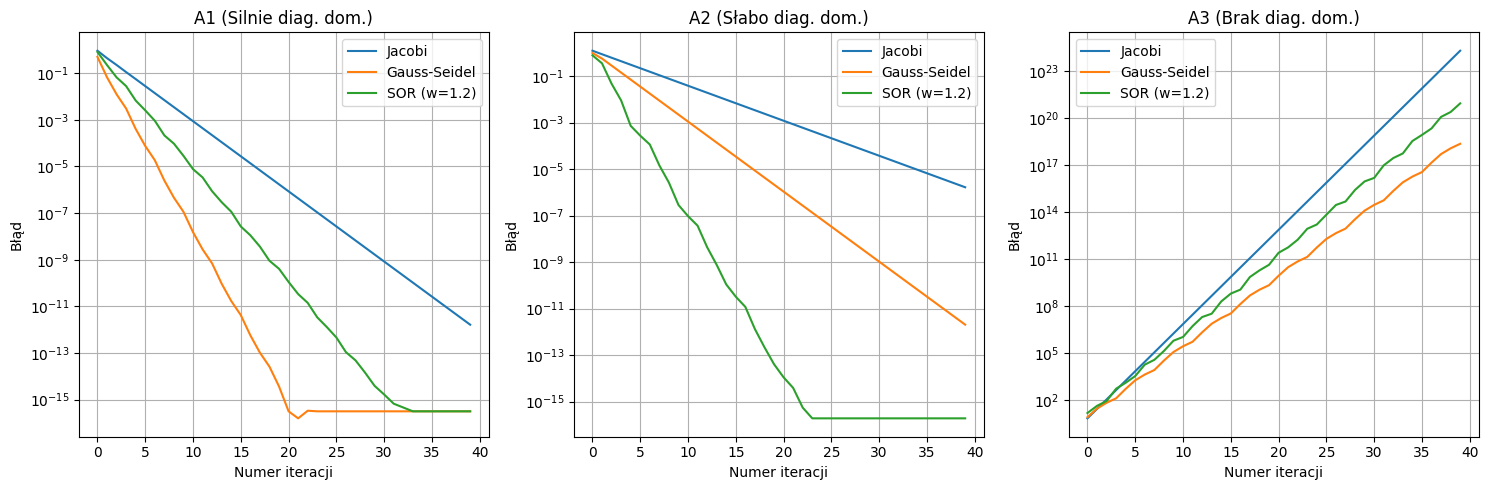

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


def jacobi(A, b, max_iter=50, x_exact=None):
    n = len(b)
    x = np.zeros(n)
    D = np.diag(np.diag(A))
    L = -np.tril(A, -1)
    U = -np.triu(A, 1)
    D_inv = np.linalg.inv(D)
    errors = []
    for _ in range(max_iter):
        x = D_inv @ (L + U) @ x + D_inv @ b
        if x_exact is not None:
            errors.append(np.linalg.norm(x - x_exact))
    return x, errors

def gauss_seidel(A, b, max_iter=50, x_exact=None):
    n = len(b)
    x = np.zeros(n)
    D = np.diag(np.diag(A))
    L = -np.tril(A, -1)
    U = -np.triu(A, 1)
    DL_inv = np.linalg.inv(D - L)
    errors = []
    for _ in range(max_iter):
        x = DL_inv @ U @ x + DL_inv @ b
        if x_exact is not None:
            errors.append(np.linalg.norm(x - x_exact))
    return x, errors

def sor(A, b, omega=1.2, max_iter=50, x_exact=None):
    n = len(b)
    x = np.zeros(n)
    D = np.diag(np.diag(A))
    L = -np.tril(A, -1)
    U = -np.triu(A, 1)
    M_inv = np.linalg.inv(D - omega * L)
    errors = []
    for _ in range(max_iter):
        x = M_inv @ (((1 - omega) * D + omega * U) @ x + omega * b)
        if x_exact is not None:
            errors.append(np.linalg.norm(x - x_exact))
    return x, errors


A1 = np.array([[5., 1., 1.], [1., 4., 1.], [2., 0., 3.]])
b1 = np.array([7., 6., 5.])

A2 = np.array([[2., -1., 0.], [-1., 2., -1.], [0., -1., 2.]])
b2 = np.array([1., 0., 1.])

A3 = np.array([[1., 2., 2.], [2., 1., 2.], [2., 2., 1.]])
b3 = np.array([5., 5., 5.])

matrices = [(A1, b1, "A1 (Silnie diag. dom.)"), 
            (A2, b2, "A2 (Słabo diag. dom.)"), 
            (A3, b3, "A3 (Brak diag. dom.)")]


plt.figure(figsize=(15, 5))

for idx, (A, b, title) in enumerate(matrices):
   
    x_exact = np.linalg.solve(A, b)
    
    
    _, err_jacobi = jacobi(A, b, max_iter=40, x_exact=x_exact)
    _, err_gs = gauss_seidel(A, b, max_iter=40, x_exact=x_exact)
    _, err_sor = sor(A, b, omega=1.2, max_iter=40, x_exact=x_exact)
    
    
    plt.subplot(1, 3, idx+1)
    plt.semilogy(err_jacobi, label='Jacobi')
    plt.semilogy(err_gs, label='Gauss-Seidel')
    plt.semilogy(err_sor, label='SOR (w=1.2)')
    plt.title(title)
    plt.xlabel('Numer iteracji')
    plt.ylabel('Błąd')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Porównanie rozwiązania za pomocą metody `solve` oraz z użyciem odwrotności na przykładzie macierzy źle uwarunkowanej

***Zadanie 5.***

Dany jest układ równań $Hx=b$.
* H jest macierzą Hilberta o wymiarach $n=5x5$ (I przypadek) i $n=15x15$ (II przypadek),
* b jest wektorem o następujących elementach $b_i = 1/(n + i + 1)$ Uwaga: $i=1,\dots,n$.

Do rozwiązania układu wykorzystaj dwa algorytmy:
1. Z odwracaniem macierzy współczynników H.
2. Metodę `numpy.linalg.solve`.

Porównaj błędy obu rozwiązań. Aby ocenić błąd możesz:
* wyznaczyć wektor residuum otrzymanego rozwiązania,
* rozwiązać układ równań z innym wektorem $b$. Załóż, że wektor rozwiązania ma wszystkie elementy (współrzędne) równe 1 ($u_i = 1, i = 1, 2, . . . , n$). Wtedy $b = Hu$. Układ rozwiążemy bez korzystania z wiedzy o postaci $u$. Dopiero wynik porównamy ze znanym nam $u$.

In [5]:
import numpy as np
from scipy.linalg import hilbert

def analyze_hilbert_system(n):
    print(f"\n{'='*50}")
    print(f" Analiza układu dla macierzy Hilberta {n}x{n}")
    print(f"{'='*50}")
    
    
    H = hilbert(n)
    
   
    i_vals = np.arange(1, n + 1)
    b = 1.0 / (n + i_vals + 1)
    
    
    H_inv = np.linalg.inv(H)
    x_inv = H_inv @ b
    res_inv = np.linalg.norm(b - H @ x_inv) 
    
    
    x_solve = np.linalg.solve(H, b)
    res_solve = np.linalg.norm(b - H @ x_solve) 
    
    print("CZĘŚĆ 1: Porównanie residuum r = |b - Hx|")
    print(f"  Metoda odwracania (inv): {res_inv:.4e}")
    print(f"  Metoda solvera (solve):  {res_solve:.4e}\n")
    
    
    u = np.ones(n)
    
    
    b_u = H @ u 
    
   
    x_inv_u = H_inv @ b_u
    x_solve_u = np.linalg.solve(H, b_u)
    
    
    err_inv_u = np.linalg.norm(u - x_inv_u)
    err_solve_u = np.linalg.norm(u - x_solve_u)
    
    print("CZĘŚĆ 2: Porównanie błędu rzeczywistego dla znanego u = [1, ..., 1]")
    print(f"  Metoda odwracania (inv): {err_inv_u:.4e}")
    print(f"  Metoda solvera (solve):  {err_solve_u:.4e}")


analyze_hilbert_system(5)
analyze_hilbert_system(15)


 Analiza układu dla macierzy Hilberta 5x5
CZĘŚĆ 1: Porównanie residuum r = |b - Hx|
  Metoda odwracania (inv): 1.1801e-12
  Metoda solvera (solve):  1.6711e-16

CZĘŚĆ 2: Porównanie błędu rzeczywistego dla znanego u = [1, ..., 1]
  Metoda odwracania (inv): 9.1600e-11
  Metoda solvera (solve):  3.7630e-12

 Analiza układu dla macierzy Hilberta 15x15
CZĘŚĆ 1: Porównanie residuum r = |b - Hx|
  Metoda odwracania (inv): 9.3727e-02
  Metoda solvera (solve):  2.0037e-15

CZĘŚĆ 2: Porównanie błędu rzeczywistego dla znanego u = [1, ..., 1]
  Metoda odwracania (inv): 1.7384e+03
  Metoda solvera (solve):  1.9094e+01


**Zadanie domowe. Znaczenie wskaźnika uwarunkowania macierzy w szacowaniu błędu rozwiązania**


Dana jest następująca macierz A współczynników układu dwóch równań liniowy:
$$A=\begin{bmatrix}10^5 & 9.9\cdot10^4\\1.00001& 0.99\end{bmatrix}$$

Wektor prawej strony równania $Ax=b$ dla rozwiązania x = $[1, 1]^T$ możemy wyznaczyć z równości $b = Ax$.

Należy:
* obliczyć wskaźnik uwarunkowania macierzy $A$,
* rozwiązać układ równań $Ax = b$ (nie korzystając z wiedzy o przyjętym rozwiązaniu dokładnym x) korzystając z funkcji `np.linalg.solve`,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania macierzy A,
* przeprowadzić skalowanie tak, aby macierz $A$ była wyważona wierszami,
* wyznaczyć nowe wartości wektora b tak, aby rozwiązanie dokładne się nie
zmieniło,
* obliczyć wskaźnik uwarunkowania macierzy skalowanej,
* rozwiązać układ równań tą samą metodą jak poprzednio,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania skalowanej macierzy $A$.
1. Czy błąd numeryczny rozwiązania w obu przypadkach jest tego samego rzędu?
2. Które szacowanie błędu jest bardziej zbliżone do faktycznego błędu?

In [6]:
import numpy as np


A = np.array([[10**5, 9.9 * 10**4],
              [1.00001, 0.99]])

x_exact = np.array([1.0, 1.0])


b = A @ x_exact


eps = np.finfo(float).eps

print("="*50)
print(" CZĘŚĆ 1: MACIERZ ORYGINALNA (NIESKALOWANA)")
print("="*50)


cond_A = np.linalg.cond(A)
print(f"Wskaźnik uwarunkowania cond(A): {cond_A:.4e}")


x_num = np.linalg.solve(A, b)


err_actual = np.linalg.norm(x_num - x_exact) / np.linalg.norm(x_exact)


err_est = cond_A * eps

print(f"Błąd rzeczywisty: {err_actual:.4e}")
print(f"Błąd szacowany:   {err_est:.4e}")


print("\n" + "="*50)
print(" CZĘŚĆ 2: MACIERZ WYWAŻONA WIERSZAMI (SKALOWANA)")
print("="*50)


row_max = np.max(np.abs(A), axis=1)


D = np.diag(1.0 / row_max)


A_scaled = D @ A


b_scaled = D @ b


cond_A_scaled = np.linalg.cond(A_scaled)
print(f"Wskaźnik uwarunkowania cond(A_scaled): {cond_A_scaled:.4e}")


x_scaled_num = np.linalg.solve(A_scaled, b_scaled)


err_scaled_actual = np.linalg.norm(x_scaled_num - x_exact) / np.linalg.norm(x_exact)
err_scaled_est = cond_A_scaled * eps

print(f"Błąd rzeczywisty: {err_scaled_actual:.4e}")
print(f"Błąd szacowany:   {err_scaled_est:.4e}")

 CZĘŚĆ 1: MACIERZ ORYGINALNA (NIESKALOWANA)
Wskaźnik uwarunkowania cond(A): 2.0001e+10
Błąd rzeczywisty: 1.1158e-11
Błąd szacowany:   4.4411e-06

 CZĘŚĆ 2: MACIERZ WYWAŻONA WIERSZAMI (SKALOWANA)
Wskaźnik uwarunkowania cond(A_scaled): 4.0002e+05
Błąd rzeczywisty: 0.0000e+00
Błąd szacowany:   8.8823e-11
